In [2]:
# Install packages if needed (uncomment and run once)
# !pip install pandas numpy scikit-learn matplotlib seaborn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

import shap
import warnings
warnings.filterwarnings("ignore")


In [8]:
# Display all rows
pd.set_option('display.max_rows', None)

# Display all columns (if needed)
pd.set_option('display.max_columns', None)

# Show the entire DataFrame
df
# Export to Excel
df.to_excel("full_dataset.xlsx", index=False)

# OR export to CSV
df.to_csv("full_dataset_output.csv", index=False)
# Export to Excel
df.to_excel("full_dataset.xlsx", index=False)

# OR export to CSV
df.to_csv("full_dataset_output.csv", index=False)


In [6]:
import zipfile
import os
import pandas as pd

# Step 1: Define your full ZIP path
zip_path = r"C:\Users\kdivy\OneDrive\Desktop\COMP ANA HT DATA\COMP HT project\archive.zip"

# Step 2: Extract it to a local 'data' folder
extract_path = "data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Step 3: Check the contents of the extracted folder
print("✅ Extracted Files:", os.listdir(extract_path))

# Step 4: Load the CSV
csv_file = os.path.join(extract_path, "heart_attack_prediction_dataset.csv")
df = pd.read_csv(csv_file)

# Step 5: Preview
print("✅ Dataset Loaded:", df.shape)
df.head()


✅ Extracted Files: ['heart_attack_prediction_dataset.csv']
✅ Dataset Loaded: (8763, 26)


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [ ]:
# Check data types of each column
print(X.dtypes)

# Optionally: find non-numeric values
for col in X.columns:
    if X[col].dtype == 'object':
        print(f"⚠️ Non-numeric values in column: {col}")
        print(X[col].unique())


Patient ID                          object
Age                                  int64
Sex                                  int64
Cholesterol                          int64
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Diet                                 int64
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
Income                               int64
BMI                                float64
Triglycerides                        int64
Physical Activity Days Per Week      int64
Sleep Hours Per Day                  int64
Country                              int64
Continent                            int64
Hemisphere 

In [14]:
print("🧾 Actual Column Names:")
print(df.columns.tolist())


🧾 Actual Column Names:
['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country', 'Continent', 'Hemisphere', 'Heart Attack Risk', 'Systolic_BP', 'Diastolic_BP']


In [16]:
# Encode categorical variables
label_cols = ['Sex', 'Alcohol Consumption', 'Diet', 'Country', 'Continent', 'Hemisphere']
for col in label_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Drop Patient ID (optional)
df.drop(['Patient ID'], axis=1, inplace=True)

# Define features and target
X = df.drop('Heart Attack Risk', axis=1)
y = df['Heart Attack Risk']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Bagging Classifier": BaggingClassifier(n_estimators=100, random_state=42)
}


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target (if not already done)
X = df.drop('Heart Attack Risk', axis=1)
y = df['Heart Attack Risk']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [20]:
results = []

for name, model in models.items():
    print(f"\n📌 Model: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = round(model.score(X_test, y_test), 4)
    prec = round(np.mean(classification_report(y_test, y_pred, output_dict=True)['1']['precision']), 4)
    recall = round(np.mean(classification_report(y_test, y_pred, output_dict=True)['1']['recall']), 4)
    f1 = round(np.mean(classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']), 4)
    auc = round(roc_auc_score(y_test, y_prob), 4)

    results.append([name, acc, prec, recall, f1, auc])
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))



📌 Model: Random Forest
[[1104   21]
 [ 612   16]]
              precision    recall  f1-score   support

           0       0.64      0.98      0.78      1125
           1       0.43      0.03      0.05       628

    accuracy                           0.64      1753
   macro avg       0.54      0.50      0.41      1753
weighted avg       0.57      0.64      0.52      1753


📌 Model: AdaBoost
[[1125    0]
 [ 628    0]]
              precision    recall  f1-score   support

           0       0.64      1.00      0.78      1125
           1       0.00      0.00      0.00       628

    accuracy                           0.64      1753
   macro avg       0.32      0.50      0.39      1753
weighted avg       0.41      0.64      0.50      1753


📌 Model: Decision Tree
[[701 424]
 [387 241]]
              precision    recall  f1-score   support

           0       0.64      0.62      0.63      1125
           1       0.36      0.38      0.37       628

    accuracy                          

In [28]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:

# ---------------------------------------------
# 1. Imports
# ---------------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------
# 2. Load Data
# ---------------------------------------------
df = pd.read_csv("data/heart_attack_prediction_dataset.csv")

# ---------------------------------------------
# 3. Drop ID & Fix BP if needed
# ---------------------------------------------
df.drop(columns=['Patient ID'], inplace=True)  # Already has Systolic/Diastolic

# ---------------------------------------------
# 4. Encode Categorical Columns
# ---------------------------------------------
label_cols = ['Sex', 'Alcohol Consumption', 'Diet', 'Country', 'Continent', 'Hemisphere']
for col in label_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# ---------------------------------------------
# 5. Feature / Target Split
# ---------------------------------------------
# ✅ Split Blood Pressure into Systolic and Diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(float)

# ✅ Drop original string-based BP column
df.drop('Blood Pressure', axis=1, inplace=True)
X = df.drop('Heart Attack Risk', axis=1)
y = df['Heart Attack Risk']


# ---------------------------------------------
# 6. Scale Features
# ---------------------------------------------
# Scale the numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ---------------------------------------------
# 7. Handle Class Imbalance using SMOTE
# ---------------------------------------------
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y)

# ---------------------------------------------
# 8. Train-Test Split (after SMOTE)
# ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# ---------------------------------------------
# 9. Define Models (with class_weight where applicable)
# ---------------------------------------------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Bagging Classifier": BaggingClassifier(n_estimators=100, random_state=42)
}

# ---------------------------------------------
# 10. Train Models and Store Results
# ---------------------------------------------
results = []
for name, model in models.items():
    print(f"\n📌 Model: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # Metrics for class 1
    report = classification_report(y_test, y_pred, output_dict=True)

    acc = model.score(X_test, y_test) * 100
    prec = report['1']['precision'] * 100
    recall = report['1']['recall'] * 100
    f1 = report['1']['f1-score'] * 100
    auc = roc_auc_score(y_test, y_prob)  # ✅ Keep as float (not percentage)

    results.append([
        name,
        f"{acc:.2f}%",
        f"{prec:.2f}%",
        f"{recall:.2f}%",
        f"{f1:.2f}%",
        round(auc, 4)  # ✅ Optional: round to 4 decimal places
    ])

# Create and sort DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"])
results_df = results_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)

print("\n✅ Synced Model Performance Table (ROC as float):")
display(results_df)

# ---------------------------------------------
# 11. Create Results Table
# ---------------------------------------------
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"])
results_df = results_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)

# ---------------------------------------------
# 12. Show Final Summary Table
# ---------------------------------------------
print("✅ Final Model Comparison Table (with SMOTE & Balanced Classes):")
display(results_df)



📌 Model: Random Forest
[[985 140]
 [435 690]]
              precision    recall  f1-score   support

           0       0.69      0.88      0.77      1125
           1       0.83      0.61      0.71      1125

    accuracy                           0.74      2250
   macro avg       0.76      0.74      0.74      2250
weighted avg       0.76      0.74      0.74      2250


📌 Model: AdaBoost
[[863 262]
 [557 568]]
              precision    recall  f1-score   support

           0       0.61      0.77      0.68      1125
           1       0.68      0.50      0.58      1125

    accuracy                           0.64      2250
   macro avg       0.65      0.64      0.63      2250
weighted avg       0.65      0.64      0.63      2250


📌 Model: Naive Bayes
[[582 543]
 [457 668]]
              precision    recall  f1-score   support

           0       0.56      0.52      0.54      1125
           1       0.55      0.59      0.57      1125

    accuracy                           0.56     

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,74.44%,83.13%,61.33%,70.59%,0.7913
1,Bagging Classifier,74.27%,83.96%,60.00%,69.98%,0.7829
2,AdaBoost,63.60%,68.43%,50.49%,58.11%,0.6901
3,Decision Tree,63.82%,63.21%,66.13%,64.64%,0.6382
4,Naive Bayes,55.56%,55.16%,59.38%,57.19%,0.5865
5,Logistic Regression,50.84%,50.82%,52.62%,51.70%,0.5114


✅ Final Model Comparison Table (with SMOTE & Balanced Classes):


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,74.44%,83.13%,61.33%,70.59%,0.7913
1,Bagging Classifier,74.27%,83.96%,60.00%,69.98%,0.7829
2,AdaBoost,63.60%,68.43%,50.49%,58.11%,0.6901
3,Decision Tree,63.82%,63.21%,66.13%,64.64%,0.6382
4,Naive Bayes,55.56%,55.16%,59.38%,57.19%,0.5865
5,Logistic Regression,50.84%,50.82%,52.62%,51.70%,0.5114


In [62]:
def plot_model_report_bar(name, model, X_test, y_test):
    from sklearn.metrics import classification_report
    import matplotlib.pyplot as plt

    # Get predictions and metrics
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)

    precision = report['1']['precision'] * 100
    recall = report['1']['recall'] * 100
    f1 = report['1']['f1-score'] * 100
    accuracy = model.score(X_test, y_test) * 100

    metrics = [precision, recall, f1, accuracy]
    labels = ['Precision', 'Recall', 'F1-Score', 'Accuracy']

    # Plotting
    plt.figure(figsize=(6, 5))
    bars = plt.bar(labels, metrics, color='forestgreen')

    for bar in bars:
        yval = bar.get_height()
        # Show label even if it's very low
        label_y = yval + 1 if yval < 90 else yval - 3
        label_color = 'black' if yval < 90 else 'white'
        plt.text(bar.get_x() + bar.get_width()/2.0, label_y, f"{yval:.2f}%", ha='center', color=label_color, fontsize=10)

    plt.ylim(0, 100)  # ✅ Force Y-axis to show 0% to 100%
    plt.ylabel("Percentage %")
    plt.xlabel("Performance Metrics")
    plt.title(f"Classification Report of {name} Model")
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [63]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curve(name, model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve\n{name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


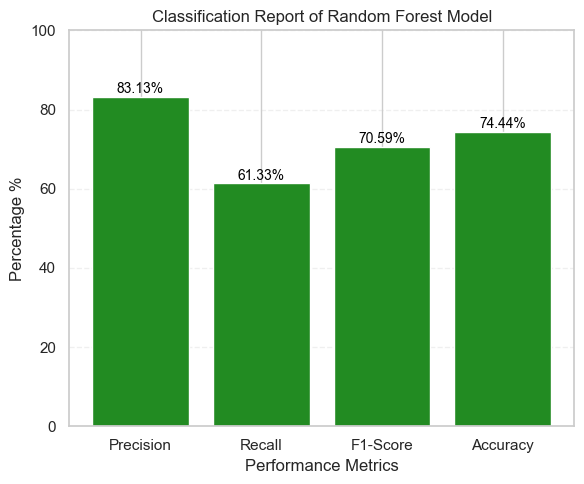

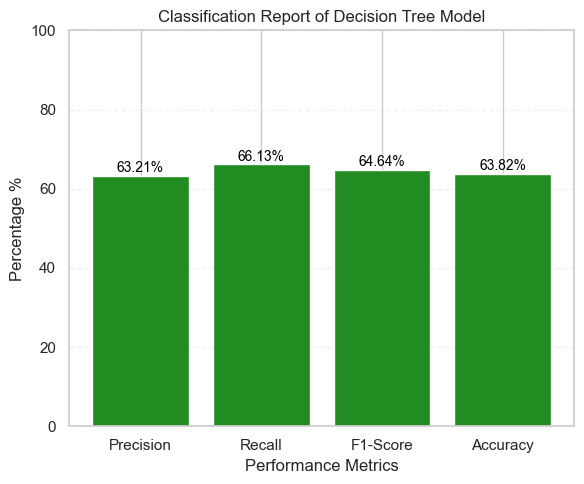

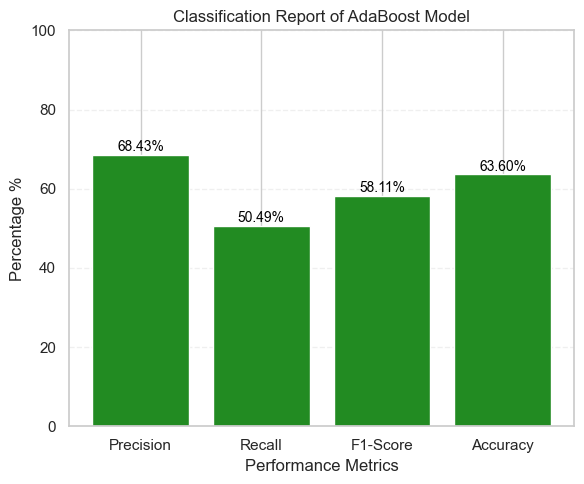

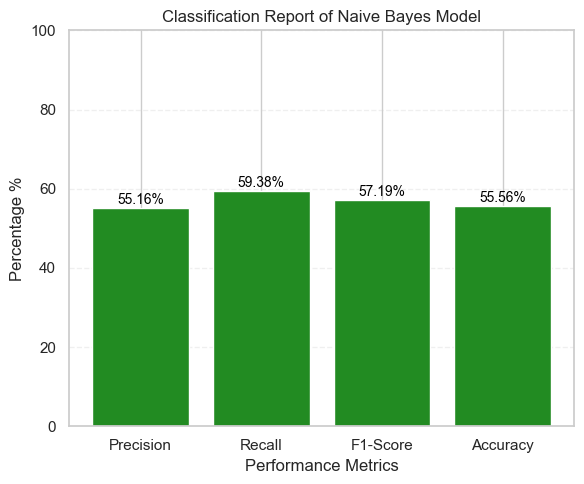

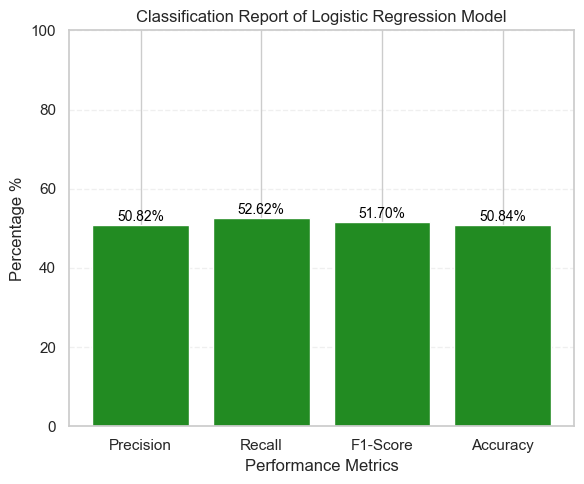

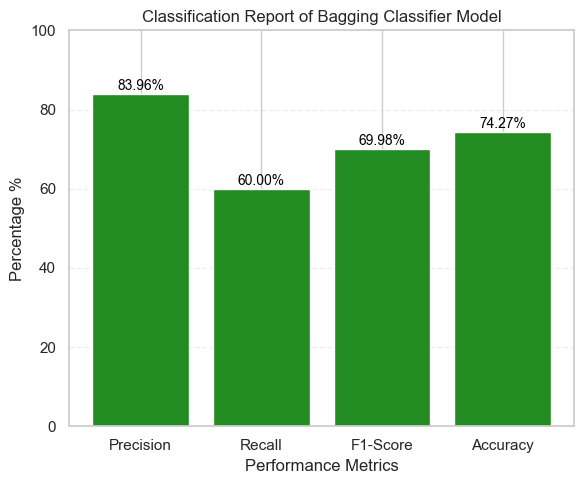

In [64]:
plot_model_report_bar("Random Forest", models["Random Forest"], X_test, y_test)
plot_model_report_bar("Decision Tree", models["Decision Tree"], X_test, y_test)
plot_model_report_bar("AdaBoost", models["AdaBoost"], X_test, y_test)
plot_model_report_bar("Naive Bayes", models["Naive Bayes"], X_test, y_test)
plot_model_report_bar("Logistic Regression", models["Logistic Regression"], X_test, y_test)
plot_model_report_bar("Bagging Classifier", models["Bagging Classifier"], X_test, y_test)

📊 Plotting for: Random Forest


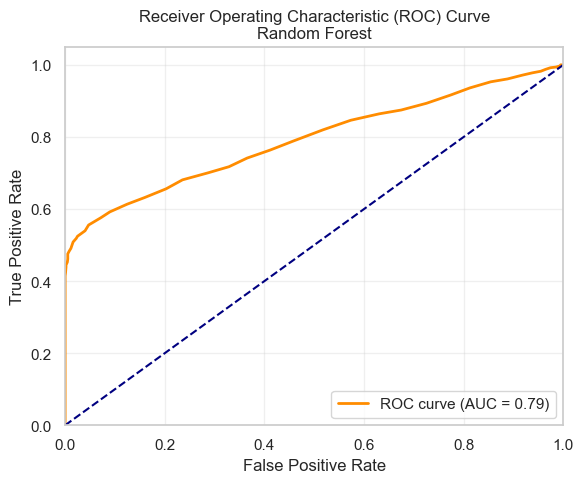

📊 Plotting for: AdaBoost


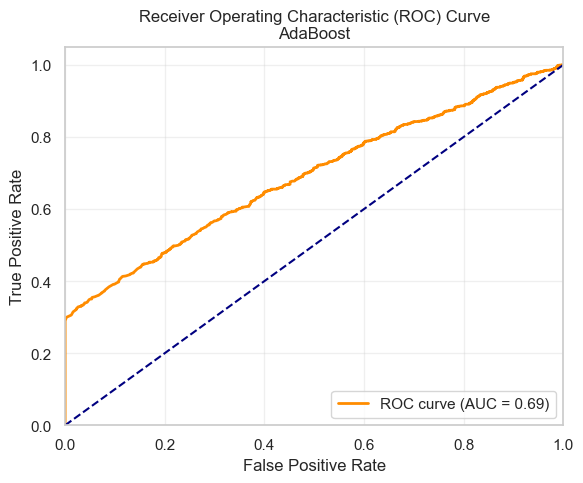

📊 Plotting for: Naive Bayes


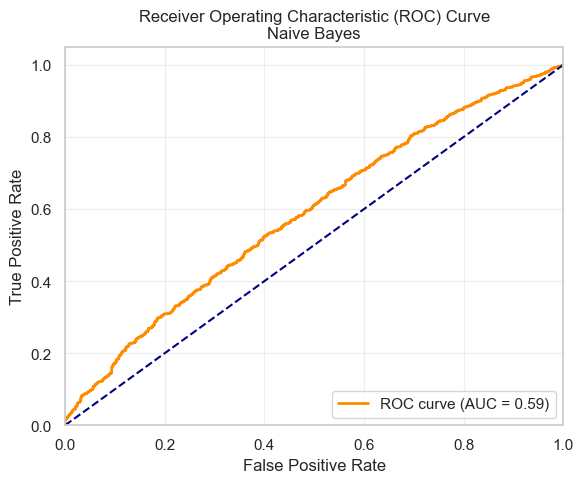

📊 Plotting for: Logistic Regression


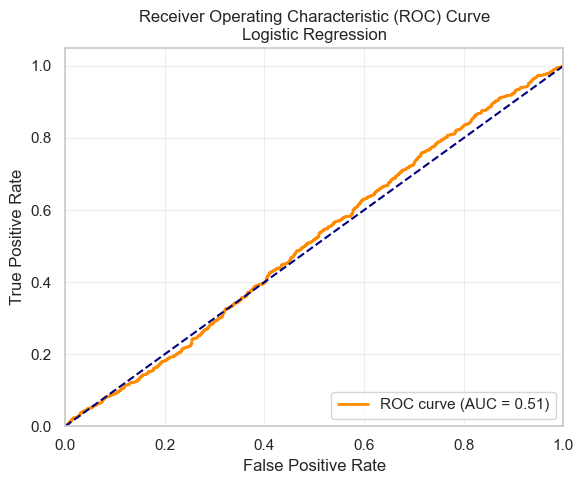

📊 Plotting for: Decision Tree


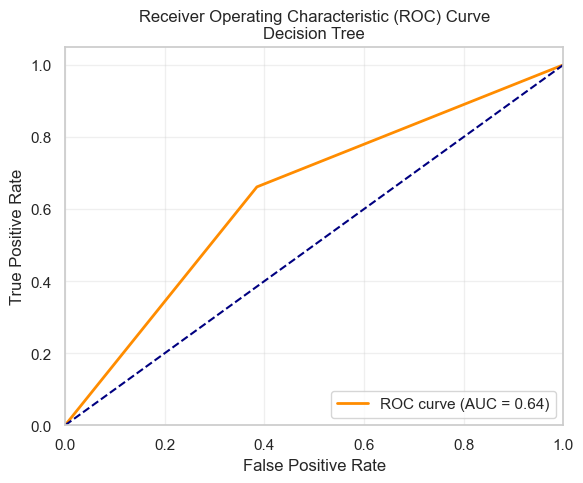

📊 Plotting for: Bagging Classifier


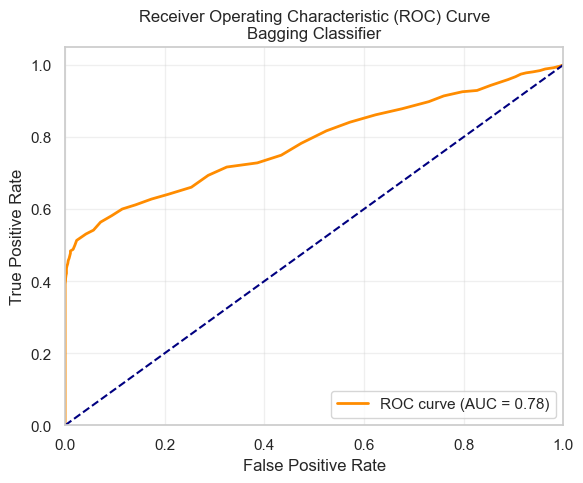

In [65]:
# Loop through all trained models
for model_name, model in models.items():
    print(f"📊 Plotting for: {model_name}")
    plot_roc_curve(model_name, model, X_test, y_test)


In [66]:
def plot_confusion_matrix_nice(name, model, X_test, y_test):
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum() * 100

    annotated = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annotated[i, j] = f"{cm[i,j]}\n{cm_norm[i,j]:.2f}%"

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=annotated, fmt='', cmap='viridis', cbar=True, square=True,
                xticklabels=[0, 1], yticklabels=[0, 1],
                annot_kws={"fontsize": 11, "fontweight": "bold", "color": "white"})

    plt.title(f"Confusion Matrix of {name} Model")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    plt.close()  # ✅ Important to avoid back-to-back rendering issues



📊 Confusion Matrix for: Random Forest


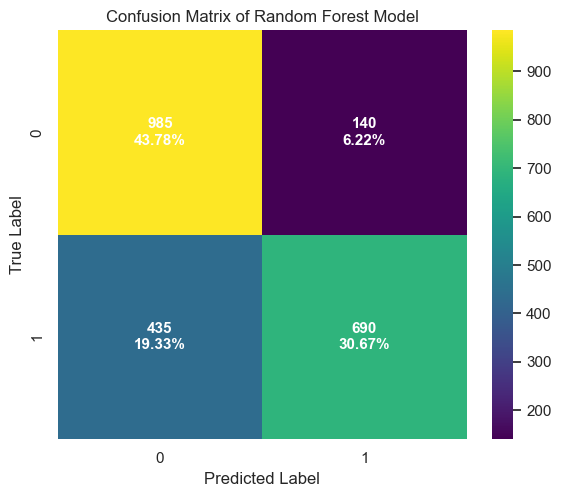


📊 Confusion Matrix for: AdaBoost


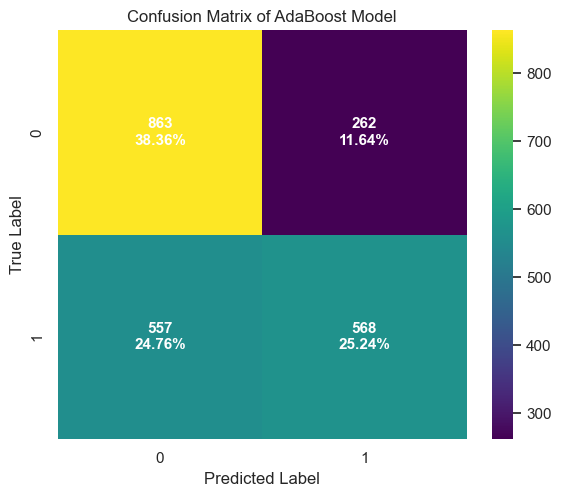


📊 Confusion Matrix for: Naive Bayes


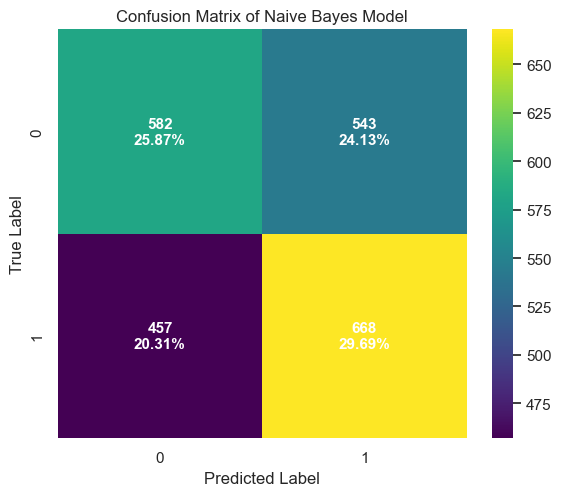


📊 Confusion Matrix for: Logistic Regression


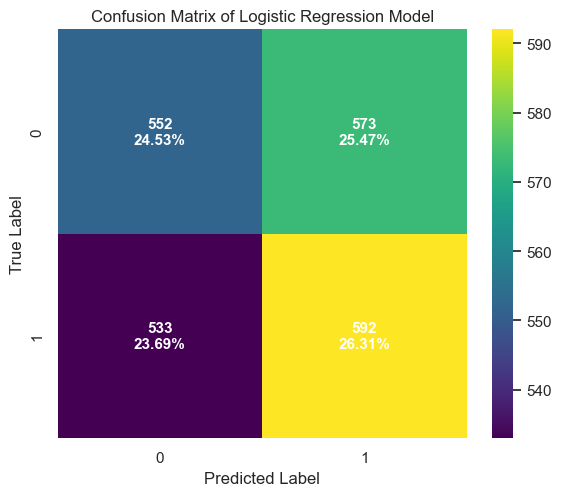


📊 Confusion Matrix for: Decision Tree


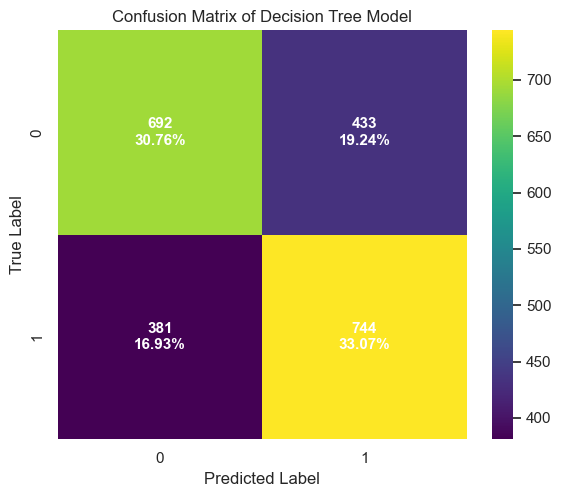


📊 Confusion Matrix for: Bagging Classifier


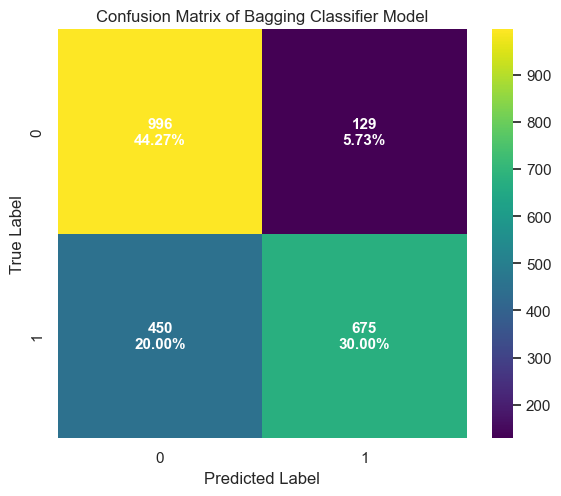

In [67]:
# ✅ This will loop through all 6 models once
for model_name, model in models.items():
    print(f"\n📊 Confusion Matrix for: {model_name}")
    plot_confusion_matrix_nice(model_name, model, X_test, y_test)


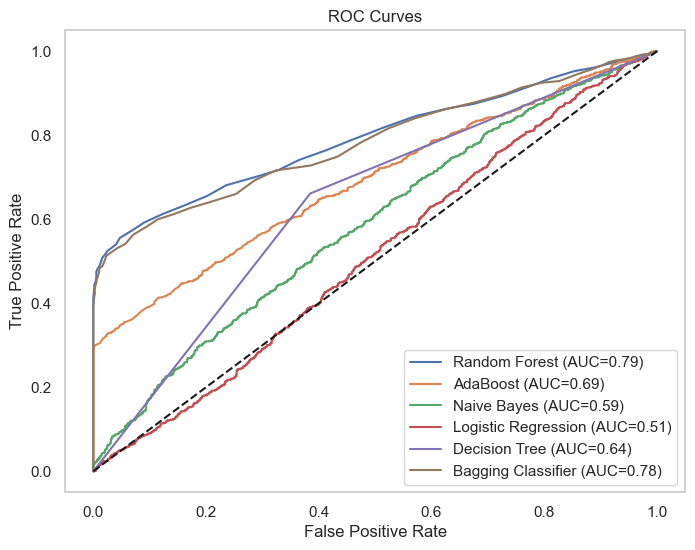

In [68]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid()
plt.show()


In [73]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_grouped_comparison_bar(results_df):
    # Clean percentage strings to float
    results_df_clean = results_df.copy()
    for col in ['Precision', 'Recall', 'F1 Score', 'Accuracy']:
        results_df_clean[col] = results_df_clean[col].str.replace('%', '').astype(float)

    models = results_df_clean['Model'].tolist()
    precision = results_df_clean['Precision'].values
    recall = results_df_clean['Recall'].values
    f1 = results_df_clean['F1 Score'].values
    accuracy = results_df_clean['Accuracy'].values

    x = np.arange(len(models))
    width = 0.2

    plt.figure(figsize=(12, 5))
    bars1 = plt.bar(x - 1.5*width, precision, width, label='Precision', color='royalblue')
    bars2 = plt.bar(x - 0.5*width, recall, width, label='Recall', color='darkorange')
    bars3 = plt.bar(x + 0.5*width, f1, width, label='F1-Score', color='gray')
    bars4 = plt.bar(x + 1.5*width, accuracy, width, label='Accuracy', color='gold')

    # Add values on top of each bar
    for bars in [bars1, bars2, bars3, bars4]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.5, f"{height:.2f}", ha='center', va='bottom', fontsize=9)

    plt.xlabel("MACHINE LEARNING CLASSIFIERS", fontsize=12, fontweight='bold')
    plt.ylabel("PERCENTAGE (%)", fontsize=12, fontweight='bold')
    plt.title("COMPARISON CHART FOR PERFORMANCE\nMATRICES", fontsize=16, fontweight='bold')
    plt.xticks(x, models, rotation=15, ha='center', fontsize=10)
    plt.ylim(0, 105)
    plt.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.15), fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

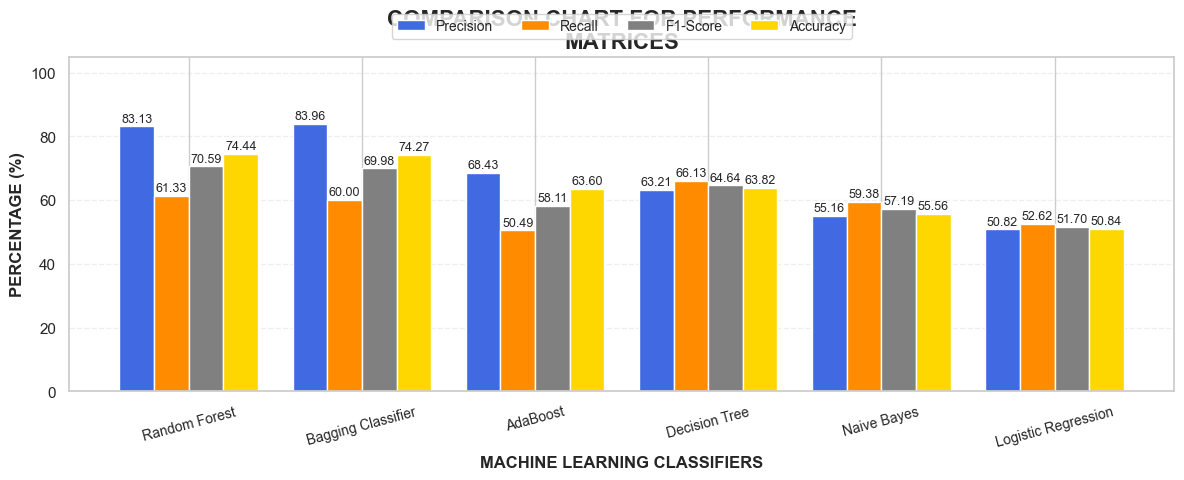

In [74]:
plot_grouped_comparison_bar(results_df)


In [79]:
X_test = pd.DataFrame(X_test, columns=X.columns)


In [80]:
import shap

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(models["Random Forest"])

# Get SHAP values for binary classification — positive class (label 1)
shap_values = explainer.shap_values(X_test, check_additivity=False)

# Check if it's a list (it usually is for binary classification)
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]  # positive class
else:
    shap_values_plot = shap_values


<Figure size 640x480 with 0 Axes>

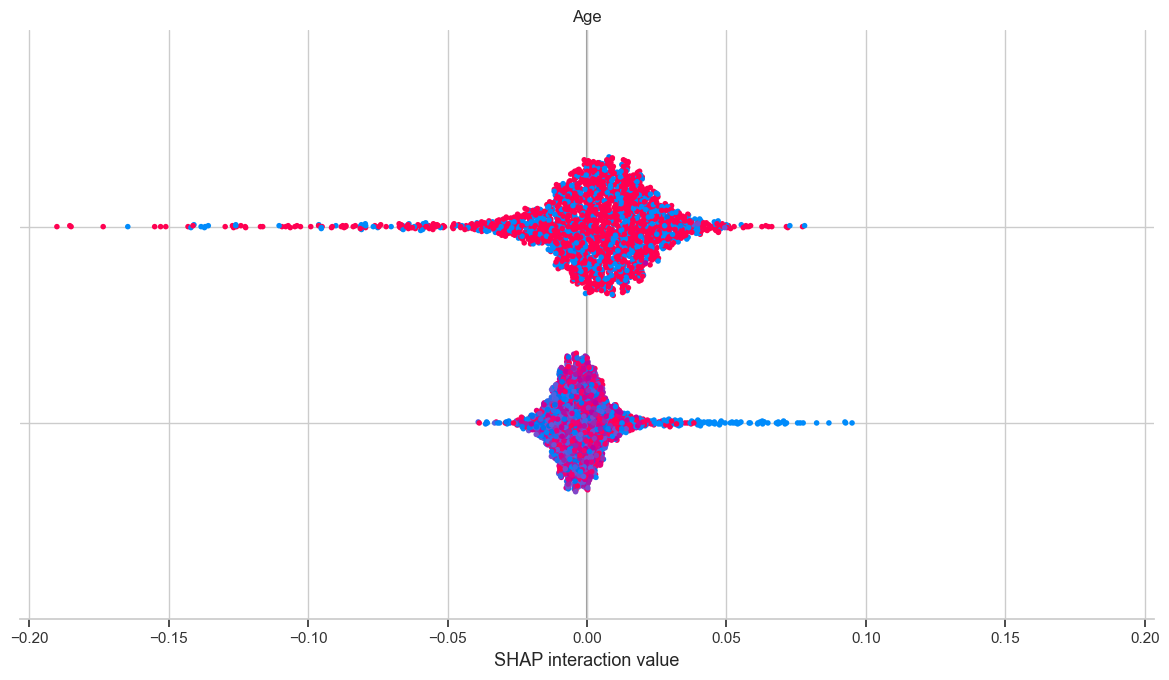

In [81]:
# SHAP beeswarm plot
shap.summary_plot(shap_values_plot, X_test, plot_type="dot", feature_names=X.columns)
